# Benchmarking: vLLM vs. SGLang Inference Engine Benchmarking

This Jupyter Notebook contains the data analysis for the A3 assignment, which compares the **vLLM (v0.28.0)** and **SGLang (v0.5.19)** inference engines on an **ASUS Ascent GX10 (NVIDIA GB10 Grace-Blackwell, 128 GB unified-memory)** workstation.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({'font.size': 10, 'figure.titlesize': 12, 'axes.labelsize': 10})
print('Libraries imported successfully.')


Libraries imported successfully.


## 1. Load Data
Load the experimental data from `data/Run_Table.csv` and `data/Run_Table_derived.csv`.


In [31]:
DATA_DIR = Path('data')
run_table_path = DATA_DIR / 'Run_Table.csv'
derived_path = DATA_DIR / 'Run_Table_derived.csv'

df_raw = pd.read_csv(run_table_path)
df_derived = pd.read_csv(derived_path)

df = pd.merge(df_raw, df_derived, on='__run_id')
df.rename(columns={'__run_id': 'run_id'}, inplace=True)

print(f'Total records loaded: {len(df)}')
print(f'Valid runs: {df["valid"].sum()} / {len(df)}')
print(f'Models evaluated: {list(df["model"].unique())}')
print(f'Engines evaluated: {list(df["engine"].unique())}')
print(f'Prompt profiles: {list(df["profile"].unique())}')
print(f'Context sizes: {list(df["context"].unique())}')
df.head()


Total records loaded: 260
Valid runs: 260 / 260
Models evaluated: ['llama', 'qwen']
Engines evaluated: ['sglang', 'vllm']
Prompt profiles: ['agentic', 'chat', 'api']
Context sizes: ['medium', 'large', 'small']


,run_id,__done,model,engine,profile,context,valid,invalid_reason,n_requests,n_errors,...,gpu_util_mean_pct,cpu_util_mean_pct,engine_start_s,contaminated,block,E_gpu_pint_J,E_tok_pint_J,P_gpu_pint_W,EDP_pint_Js,pint_vs_counter_pct
0,run_16_repetition_0,DONE,llama,sglang,agentic,medium,1,NaN,176,0,...,95.495,6.777,182.13,0,1,8909.4518,0.395483,42.2315,1879600.328,8.884
1,run_17_repetition_0,DONE,llama,sglang,agentic,large,1,NaN,120,0,...,95.524,7.600,173.13,0,1,11634.0915,0.757428,54.2688,2494104.898,2.790
2,run_5_repetition_0,DONE,llama,vllm,chat,large,1,NaN,128,0,...,95.617,1.896,141.13,0,1,14654.3999,0.894434,53.1602,4039705.153,17.275
3,run_6_repetition_0,DONE,llama,vllm,agentic,small,1,NaN,192,0,...,95.642,3.413,114.09,0,1,7939.3079,0.323051,37.5754,1677496.357,15.255
4,run_8_repetition_0,DONE,llama,vllm,agentic,large,1,NaN,120,0,...,95.556,3.179,141.09,0,1,13446.3193,0.875411,56.5894,3195006.829,9.980


## 2. Descriptive Statistics by Metric
Each table below reports one metric for every experimental cell (model, prompt profile, context size, and engine). This keeps the interpretation of each measure separate.

- **`E_tok_J`**: GPU energy used per generated output token (J/token). Lower is better.
- **`E_tok_pint_J`**: Alternative energy per output token, obtained by integrating sampled GPU power (J/token).
- **`P_gpu_mean_W`**: Mean GPU power draw during the measured window (W).
- **`window_s`**: Duration of the measured workload window (seconds).
- **`cpu_util_mean_pct`**: Mean host CPU utilisation during the measured window (%).
- **`T_gen_tps`**: Generated-output throughput (tokens/second). Higher is better.
- **`ttft_ms_median`**: Median time to first token (ms), representing prefill latency. Lower is better.
- **`tpot_ms_median`**: Median time per output token (ms), representing decoding latency. Lower is better.
- **`kv_peak_pct`**: Peak occupancy of the KV-cache pool (%).
- **`prefix_hit_pct`**: Share of prompt tokens served from the prefix cache (%).
- **`EDP_Js`**: Energy-delay product (J·s), combining energy consumption and run duration. Lower is better.
- **`e2e_ms_median`**: Median end-to-end request latency (ms). Lower is better.


In [32]:
metrics_interest = [
    'E_tok_J', 'E_tok_pint_J', 'P_gpu_mean_W', 'window_s',
    'cpu_util_mean_pct', 'T_gen_tps', 'ttft_ms_median',
    'tpot_ms_median', 'e2e_ms_median', 'kv_peak_pct',
    'prefix_hit_pct', 'EDP_Js'
]

summary_functions = [
    ('mean', 'mean'),
    ('median', 'median'),
    ('std_dev', 'std'),
    ('IQR', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ('min', 'min'),
    ('max', 'max')
]

metric_tables = {}
for metric in metrics_interest:
    metric_tables[metric] = (
        df.groupby(['model', 'profile', 'context', 'engine'])[metric]
        .agg(summary_functions)
        .round(4)
    )

for metric, table in metric_tables.items():
    print(f'\n=== {metric} ===')
    display(table)




=== E_tok_J ===


mean  median  std_dev     IQR     min     max
model profile context engine                                                 
llama agentic large   sglang  0.6876  0.6856   0.0386  0.0656  0.6399  0.7369
                      vllm    0.7945  0.7862   0.0385  0.0613  0.7471  0.8549
              medium  sglang  0.3720  0.3739   0.0164  0.0214  0.3440  0.3934
                      vllm    0.3797  0.3833   0.0187  0.0276  0.3505  0.3996
              small   sglang  0.2914  0.2893   0.0155  0.0281  0.2720  0.3143
                      vllm    0.2952  0.2982   0.0119  0.0184  0.2803  0.3159
      api     large   sglang  1.6071  1.6251   0.0840  0.1368  1.4946  1.7082
                      vllm    1.8493  1.8338   0.0722  0.0548  1.7448  2.0113
              medium  sglang  0.5620  0.5554   0.0222  0.0120  0.5365  0.6043
                      vllm    0.5904  0.5766   0.0303  0.0376  0.5664  0.6496
              small   sglang  0.3362  0.3329   0.0118  0.0196  0.3227  0.3539
                      vllm    0.3401  0.3373   0.0136  0.0222  0.3231  0.3605
      chat    large   sglang  0.7225  0.7247   0.0433  0.0787  0.6723  0.7694
                      vllm    0.7974  0.7927   0.0357  0.0446  0.7533  0.8537
              medium  sglang  0.3830  0.3761   0.0164  0.0240  0.3664  0.4141
                      vllm    0.4026  0.4035   0.0141  0.0210  0.3829  0.4215
              small   sglang  0.3183  0.3173   0.0105  0.0164  0.3016  0.3332
                      vllm    0.3149  0.3130   0.0134  0.0222  0.2949  0.3308
qwen  agentic large   sglang  0.6040  0.6057   0.0255  0.0153  0.5470  0.6405
                      vllm    0.6578  0.6652   0.0239  0.0221  0.6137  0.6898
              small   sglang  0.2816  0.2812   0.0111  0.0141  0.2591  0.2949
                      vllm    0.2717  0.2665   0.0134  0.0132  0.2601  0.3021
      api     large   sglang  1.4069  1.4218   0.0683  0.1121  1.3164  1.4970
                      vllm    1.6210  1.6546   0.0779  0.1228  1.4887  1.6986
              small   sglang  0.3270  0.3210   0.0125  0.0190  0.3149  0.3474
                      vllm    0.3285  0.3319   0.0142  0.0256  0.3073  0.3462


=== E_tok_pint_J ===


mean  median  std_dev     IQR     min     max
model profile context engine                                                 
llama agentic large   sglang  0.7557  0.7559   0.0025  0.0030  0.7515  0.7596
                      vllm    0.8758  0.8754   0.0009  0.0011  0.8746  0.8775
              medium  sglang  0.4012  0.4018   0.0024  0.0010  0.3955  0.4046
                      vllm    0.4085  0.4103   0.0045  0.0054  0.4004  0.4132
              small   sglang  0.3213  0.3209   0.0017  0.0018  0.3196  0.3255
                      vllm    0.3237  0.3242   0.0020  0.0014  0.3185  0.3251
      api     large   sglang  1.7432  1.7575   0.0246  0.0342  1.6966  1.7668
                      vllm    2.0568  2.0596   0.0100  0.0124  2.0382  2.0697
              medium  sglang  0.6381  0.6397   0.0034  0.0027  0.6298  0.6405
                      vllm    0.6633  0.6637   0.0023  0.0012  0.6572  0.6655
              small   sglang  0.3789  0.3793   0.0014  0.0010  0.3758  0.3802
                      vllm    0.3757  0.3760   0.0011  0.0010  0.3729  0.3766
      chat    large   sglang  0.7838  0.7851   0.0067  0.0113  0.7739  0.7935
                      vllm    0.8931  0.8922   0.0030  0.0035  0.8901  0.8991
              medium  sglang  0.4266  0.4270   0.0019  0.0009  0.4215  0.4278
                      vllm    0.4356  0.4361   0.0022  0.0019  0.4315  0.4378
              small   sglang  0.3398  0.3396   0.0023  0.0014  0.3356  0.3449
                      vllm    0.3370  0.3377   0.0024  0.0029  0.3332  0.3406
qwen  agentic large   sglang  0.6456  0.6454   0.0022  0.0022  0.6423  0.6496
                      vllm    0.7155  0.7178   0.0078  0.0037  0.6979  0.7228
              small   sglang  0.3019  0.3019   0.0006  0.0010  0.3010  0.3030
                      vllm    0.3024  0.3028   0.0017  0.0008  0.2979  0.3039
      api     large   sglang  1.5208  1.5260   0.0170  0.0166  1.4863  1.5409
                      vllm    1.7663  1.7638   0.0122  0.0163  1.7425  1.7818
              small   sglang  0.3576  0.3576   0.0007  0.0006  0.3565  0.3588
                      vllm    0.3560  0.3565   0.0017  0.0017  0.3527  0.3581


=== P_gpu_mean_W ===


...

mean  median  std_dev     IQR     min     max
model profile context engine                                                  
llama agentic large   sglang  28.6544  28.656   0.0036  0.0045  28.649  28.658
                      vllm    28.7560  28.756   0.0000  0.0000  28.756  28.756
              medium  sglang   8.0010   8.003   0.0042  0.0000   7.993   8.003
                      vllm     8.1270   8.127   0.0000  0.0000   8.127   8.127
              small   sglang   2.8390   2.838   0.0032  0.0000   2.838   2.848
                      vllm     2.9690   2.969   0.0000  0.0000   2.969   2.969
      api     large   sglang  80.7418  80.735   0.0215  0.0000  80.735  80.803
                      vllm    80.7770  80.777   0.0000  0.0000  80.777  80.777
              medium  sglang  20.7433  20.746   0.0043  0.0068  20.737  20.746
                      vllm    20.8440  20.844   0.0000  0.0000  20.844  20.844
              small   sglang   5.7460   5.746   0.0000  0.0000   5.746   5.746
                      vllm     5.8410   5.841   0.0000  0.0000   5.841   5.841
      chat    large   sglang  83.7202  83.721   0.0201  0.0285  83.685  83.744
                      vllm    83.7470  83.747   0.0000  0.0000  83.747  83.747
              medium  sglang  23.7011  23.702   0.0028  0.0000  23.693  23.702
                      vllm    23.8130  23.813   0.0000  0.0000  23.813  23.813
              small   sglang   8.7020   8.704   0.0063  0.0000   8.684   8.704
                      vllm     8.8100   8.810   0.0000  0.0000   8.810   8.810
qwen  agentic large   sglang  28.6705  28.671   0.0067  0.0068  28.661  28.680
                      vllm    28.7560  28.756   0.0000  0.0000  28.756  28.756
              small   sglang   2.8500   2.850   0.0000  0.0000   2.850   2.850
                      vllm     2.9690   2.969   0.0000  0.0000   2.969   2.969
      api     large   sglang  80.9299  80.924   0.0187  0.0000  80.924  80.983
                      vllm    81.0510  81.051   0.0000  0.0000  81.051  81.051
              small   sglang   5.9340   5.934   0.0000  0.0000   5.934   5.934
                      vllm     6.1140   6.114   0.0000  0.0000   6.114   6.114


=== prefix_hit_pct ===


mean  median  std_dev     IQR     min     max
model profile context engine                                                  
llama agentic large   sglang  75.1262  75.126   0.0010  0.0000  75.125  75.128
                      vllm    75.0280  75.028   0.0000  0.0000  75.028  75.028
              medium  sglang  75.7290  75.729   0.0000  0.0000  75.729  75.729
                      vllm    75.3120  75.312   0.0000  0.0000  75.312  75.312
              small   sglang  78.0001  78.003   0.0092  0.0000  77.974  78.003
                      vllm    76.2590  76.259   0.0000  0.0000  76.259  76.259
      api     large   sglang   0.6240   0.624   0.0000  0.0000   0.624   0.624
                      vllm     0.5860   0.586   0.0000  0.0000   0.586   0.586
              medium  sglang   2.5080   2.508   0.0000  0.0000   2.508   2.508
                      vllm     2.3440   2.344   0.0000  0.0000   2.344   2.344
              small   sglang  10.1460  10.146   0.0000  0.0000  10.146  10.146
                      vllm     9.4090   9.409   0.0000  0.0000   9.409   9.409
      chat    large   sglang  74.2323  74.232   0.0005  0.0008  74.232  74.233
                      vllm    74.1690  74.169   0.0000  0.0000  74.169  74.169
              medium  sglang  71.9340  71.934   0.0000  0.0000  71.934  71.934
                      vllm    71.6790  71.679   0.0000  0.0000  71.679  71.679
              small   sglang  62.7410  62.741   0.0000  0.0000  62.741  62.741
                      vllm    61.7330  61.733   0.0000  0.0000  61.733  61.733
qwen  agentic large   sglang  75.1333  75.134   0.0011  0.0010  75.131  75.134
                      vllm    75.0380  75.038   0.0000  0.0000  75.038  75.038
              small   sglang  77.9250  77.925   0.0000  0.0000  77.925  77.925
                      vllm    76.2620  76.262   0.0000  0.0000  76.262  76.262
      api     large   sglang   0.3550   0.355   0.0000  0.0000   0.355   0.355
                      vllm     0.1950   0.195   0.0000  0.0000   0.195   0.195
              small   sglang   5.8300   5.830   0.0000  0.0000   5.830   5.830
                      vllm     3.2550   3.255   0.0000  0.0000   3.255   3.255


=== EDP_Js ===


mean        median      std_dev  \
model profile context engine                                            
llama agentic large   sglang  2.272300e+06  2.268950e+06  128260.1049   
                      vllm    2.896833e+06  2.865344e+06  135148.3841   
              medium  sglang  1.804870e+06  1.797099e+06   83312.8866   
                      vllm    1.828246e+06  1.831590e+06   90955.5330   
              small   sglang  1.508558e+06  1.501377e+06   80119.1559   
                      vllm    1.535680e+06  1.533026e+06   63521.0989   
      api     large   sglang  2.851048e+06  2.881279e+06  166354.0562   
                      vllm    3.565776e+06  3.539380e+06  144952.5304   
              medium  sglang  2.141766e+06  2.115876e+06   88428.8301   
                      vllm    2.283320e+06  2.236677e+06  124565.9925   
              small   sglang  1.733306e+06  1.725070e+06   57084.8393   
                      vllm    1.742263e+06  1.730859e+06   73503.6347   
      chat    large   sglang  3.129567e+06  3.137447e+06  216851.0251   
                      vllm    3.593324e+06  3.566242e+06  163729.5413   
              medium  sglang  1.664909e+06  1.636775e+06   71550.7617   
                      vllm    1.746716e+06  1.762114e+06   62419.0296   
              small   sglang  1.706723e+06  1.700341e+06   57108.2443   
                      vllm    1.675668e+06  1.640251e+06   73395.1097   
qwen  agentic large   sglang  2.431778e+06  2.437887e+06  102975.8367   
                      vllm    2.729449e+06  2.754098e+06  100164.6776   
              small   sglang  1.585412e+06  1.587269e+06   61790.2154   
                      vllm    1.537009e+06  1.513101e+06   79737.7955   
      api     large   sglang  3.286645e+06  3.298173e+06  160318.3207   
                      vllm    3.967035e+06  4.040398e+06  206753.0779   
              small   sglang  1.696613e+06  1.664465e+06   66247.3517   
                      vllm    1.693351e+06  1.713066e+06   78990.4907   

                                      IQR          min          max  
model profile context engine                                         
llama agentic large   sglang  223032.0630  2109535.883  2426416.556  
                      vllm    230402.8865  2727183.466  3100409.505  
              medium  sglang  143918.6590  1678604.010  1920071.967  
                      vllm     97250.6313  1661385.245  1947777.556  
              small   sglang  130718.3865  1400566.073  1636138.142  
                      vllm     96806.7567  1455468.286  1649042.079  
      api     large   sglang  268847.6653  2604192.161  3072121.090  
                      vllm    136963.2210  3409556.729  3909371.360  
              medium  sglang   36846.3725  2007293.022  2292612.837  
                      vllm    145332.0070  2144553.524  2526117.803  
              small   sglang   84604.7092  1643192.680  1823229.098  
                      vllm    129220.0035  1658691.635  1852485.061  
      chat    large   sglang  388601.8750  2865369.924  3362426.841  
                      vllm    203034.8215  3384375.745  3877582.994  
              medium  sglang  100441.8060  1595459.986  1800496.152  
                      vllm    115565.4855  1664012.862  1826647.458  
              small   sglang   78877.3040  1623653.023  1797898.812  
                      vllm    120190.8548  1574685.026  1775030.844  
qwen  agentic large   sglang   57546.8928  2204255.819  2578524.838  
                      vllm    145453.8313  2556574.192  2861376.298  
              small   sglang   77720.3727  1457171.357  1659867.639  
                      vllm     77904.8140  1451418.592  1713836.333  
      api     large   sglang  268974.6042  3078088.874  3506891.411  
                      vllm    303691.8583  3627795.529  4144725.883  
              small   sglang  102770.9020  1636381.346  1804943.893  
                      vllm    141130.0755  1578143.329  1782604.672

## 3. Normality Tests (Shapiro-Wilk)
Assess the normality assumption for each metric in each experimental cell at $\alpha = 0.05$.


In [33]:
shapiro_results = []

grouped = df.groupby(['model', 'profile', 'context', 'engine'])
for name, group in grouped:
    model, profile, context, engine = name
    for m in metrics_interest:
        vals = group[m].dropna()
        if len(vals) > 2 and vals.nunique() > 1:
            stat, p_val = stats.shapiro(vals)
            shapiro_results.append({
                'model': model, 'profile': profile, 'context': context, 'engine': engine,
                'metric': m, 'W_stat': stat, 'p_value': p_val, 'normal': p_val >= 0.05
            })

df_shapiro = pd.DataFrame(shapiro_results)
n_total = len(df_shapiro)
n_non_normal = (df_shapiro['p_value'] < 0.05).sum()
pct_non_normal = (n_non_normal / n_total) * 100

print(f'Total Shapiro-Wilk tests performed: {n_total}')
print(f'Cells rejecting normality (p < 0.05): {n_non_normal} ({pct_non_normal:.1f}%)')
print('Normality-rejection summary by metric:')
print(df_shapiro.groupby('metric')['normal'].value_counts(normalize=True).unstack().round(3))

normality_summary = pd.DataFrame({
    'Shapiro-Wilk outcome': ['Normality rejected (p < 0.05)', 'Normality not rejected (p ≥ 0.05)'],
    'Number of tests': [n_non_normal, n_total - n_non_normal],
    'Percentage': [n_non_normal / n_total * 100, (n_total - n_non_normal) / n_total * 100]
})
normality_summary['Percentage'] = normality_summary['Percentage'].round(1)
print('\nInterpretation: `normal = True` means normality is not rejected; it does not prove normality.')
normality_summary


Total Shapiro-Wilk tests performed: 274
Cells rejecting normality (p < 0.05): 132 (48.2%)
Normality-rejection summary by metric:
normal             False  True 
metric                         
EDP_Js             0.115  0.885
E_tok_J            0.192  0.808
E_tok_pint_J       0.423  0.577
P_gpu_mean_W       0.154  0.846
T_gen_tps          0.692  0.308
cpu_util_mean_pct  0.577  0.423
e2e_ms_median      0.654  0.346
kv_peak_pct        0.800  0.200
prefix_hit_pct     1.000    NaN
tpot_ms_median     0.654  0.346
ttft_ms_median     0.500  0.500
window_s           0.654  0.346

Interpretation: `normal = True` means normality is not rejected; it does not prove normality.


,Shapiro-Wilk outcome,Number of tests,Percentage
0,Normality rejected (p < 0.05),132,48.2
1,Normality not rejected (p ≥ 0.05),142,51.8


### Q-Q Graphs

A Q-Q (quantile-quantile) graph compares the observed distribution of a metric with a theoretical normal distribution. Points close to the reference line indicate approximate normality; systematic departures indicate non-normality. Here, we examine all 12 analysis metrics for the Llama API-Small condition served by vLLM.


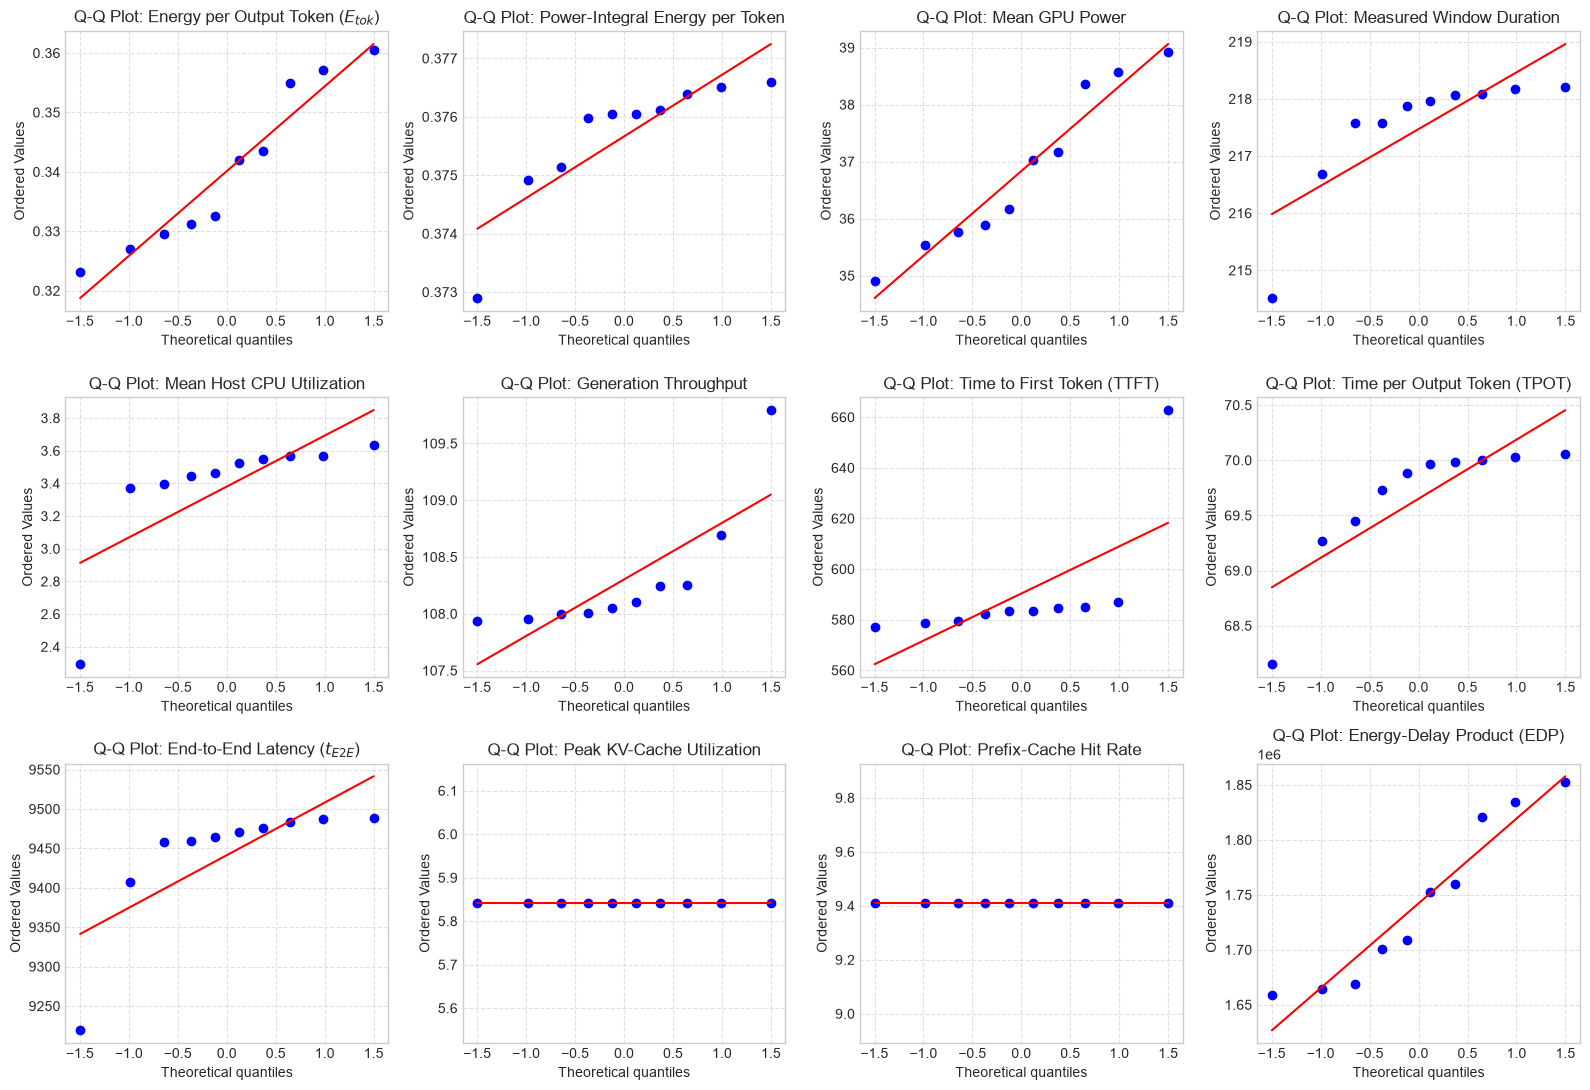

In [34]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
base_data = df[(df.model == 'llama') & (df.profile == 'api') & (df.context == 'small') & (df.engine == 'vllm')]

metrics_qq = [
    'E_tok_J', 'E_tok_pint_J', 'P_gpu_mean_W', 'window_s',
    'cpu_util_mean_pct', 'T_gen_tps', 'ttft_ms_median', 'tpot_ms_median',
    'e2e_ms_median', 'kv_peak_pct', 'prefix_hit_pct', 'EDP_Js'
]
titles = [
    'Energy per Output Token ($E_{tok}$)', 'Power-Integral Energy per Token',
    'Mean GPU Power', 'Measured Window Duration',
    'Mean Host CPU Utilization', 'Generation Throughput',
    'Time to First Token (TTFT)', 'Time per Output Token (TPOT)',
    'End-to-End Latency ($t_{E2E}$)', 'Peak KV-Cache Utilization',
    'Prefix-Cache Hit Rate', 'Energy-Delay Product (EDP)'
]

for ax, m, t in zip(axes.flatten(), metrics_qq, titles):
    stats.probplot(base_data[m], dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {t}')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 4. Baseline-Condition Analysis (RQ1 and RQ2)
Evaluate differences between vLLM and SGLang in the baseline condition (API $\times$ Small: 512 input tokens, 128 output tokens, concurrency 8).


In [35]:
def cliff_delta(x, y):
    n1, n2 = len(x), len(y)
    m = np.subtract.outer(x, y)
    delta = (np.sum(m > 0) - np.sum(m < 0)) / (n1 * n2)
    abs_d = abs(delta)
    if abs_d < 0.147:
        mag = 'negligible'
    elif abs_d < 0.33:
        mag = 'small'
    elif abs_d < 0.474:
        mag = 'medium'
    else:
        mag = 'large'
    return delta, mag

base_df = df[(df.model == 'llama') & (df.profile == 'api') & (df.context == 'small')]
v_data = base_df[base_df.engine == 'vllm']
s_data = base_df[base_df.engine == 'sglang']

rq1_rq2_results = []
test_metrics = [
    ('RQ1.1 Energy per Token', 'E_tok_J'),
    ('RQ1.2 Host CPU Utilization', 'cpu_util_mean_pct'),
    ('RQ2.1 Generation Throughput', 'T_gen_tps'),
    ('RQ2.2 Time-to-First-Token', 'ttft_ms_median'),
    ('RQ2.3 Time-per-Output-Token', 'tpot_ms_median'),
    ('RQ2.4 Peak KV-Cache Util', 'kv_peak_pct')
]

for label, m in test_metrics:
    v_vals = v_data[m].values
    s_vals = s_data[m].values
    u_stat, p_val = stats.mannwhitneyu(s_vals, v_vals, alternative='two-sided')
    delta_val, mag = cliff_delta(s_vals, v_vals)
    diff_pct = 100 * (np.median(s_vals) / np.median(v_vals) - 1)
    
    rq1_rq2_results.append({
        'Research Question': label,
        'Metric': m,
        'vLLM Median': np.median(v_vals),
        'SGLang Median': np.median(s_vals),
        'Difference (%)': diff_pct,
        'Mann-Whitney U': u_stat,
        'p-value': p_val,
        "Cliff's Delta": delta_val,
        'Magnitude': mag
    })

df_base_res = pd.DataFrame(rq1_rq2_results)
df_base_res


,Research Question,Metric,vLLM Median,SGLang Median,Difference (%),Mann-Whitney U,p-value,Cliff's Delta,Magnitude
0,RQ1.1 Energy per Token,E_tok_J,0.337294,0.332918,-1.297238,37.0,0.344704,-0.26,small
1,RQ1.2 Host CPU Utilization,cpu_util_mean_pct,3.493000,8.161000,133.638706,100.0,0.000183,1.00,large
2,RQ2.1 Generation Throughput,T_gen_tps,108.076000,107.097000,-0.905844,26.0,0.075662,-0.48,large
3,RQ2.2 Time-to-First-Token,ttft_ms_median,583.443500,878.066000,50.497178,100.0,0.000183,1.00,large
4,RQ2.3 Time-per-Output-Token,tpot_ms_median,69.928000,68.401000,-2.183675,6.0,0.001008,-0.88,large
5,RQ2.4 Peak KV-Cache Util,kv_peak_pct,5.841000,5.746000,-1.626434,0.0,0.000016,-1.00,large


In [36]:
def gmean(x):
    return np.exp(np.mean(np.log(x)))

E_v = gmean(v_data['E_gpu_J'])
E_s = gmean(s_data['E_gpu_J'])
P_v = gmean(v_data['P_gpu_mean_W'])
P_s = gmean(s_data['P_gpu_mean_W'])
t_v = gmean(v_data['window_s'])
t_s = gmean(s_data['window_s'])

ln_E = np.log(E_s / E_v)
ln_P = np.log(P_s / P_v)
ln_t = np.log(t_s / t_v)

print('=== RQ1.3 Exact Log-Ratio Decomposition ===')
print(f'ln(E_SGLang / E_vLLM)  [Total Energy] : {ln_E:.6f}  ({(np.exp(ln_E)-1)*100:.2f}%)')
print(f'ln(P_SGLang / P_vLLM)  [Mean Power]   : {ln_P:.6f}  ({(np.exp(ln_P)-1)*100:.2f}%)')
print(f'ln(t_SGLang / t_vLLM)  [Run Duration] : {ln_t:.6f}  ({(np.exp(ln_t)-1)*100:.2f}%)')
print(f'Check (ln_P + ln_t - ln_E)             : {ln_P + ln_t - ln_E:.10f} (exactly 0)')


=== RQ1.3 Exact Log-Ratio Decomposition ===
ln(E_SGLang / E_vLLM)  [Total Energy] : -0.011584  (-1.15%)
ln(P_SGLang / P_vLLM)  [Mean Power]   : -0.018321  (-1.82%)
ln(t_SGLang / t_vLLM)  [Run Duration] : 0.006737  (0.68%)
Check (ln_P + ln_t - ln_E)             : -0.0000008453 (exactly 0)


### Interpretation of the Baseline Condition

The report finds no statistically significant difference in GPU energy per output token between vLLM and SGLang in the API-Small baseline: SGLang is only about 1.3% lower. Throughput is likewise similar. The engines instead show a latency trade-off: SGLang has a substantially longer TTFT, while its TPOT is slightly lower. Its host CPU utilisation is also more than twice that of vLLM, a cost not captured by GPU-only energy measurement.


## 5. Baseline-Condition Comparison Plots

These boxplots compare vLLM and SGLang across the 10 runs in the Llama API-Small baseline. They show the distribution of GPU energy per output token, mean host CPU utilisation, and median time to first token (TTFT). Lower values are preferable for all three measures.


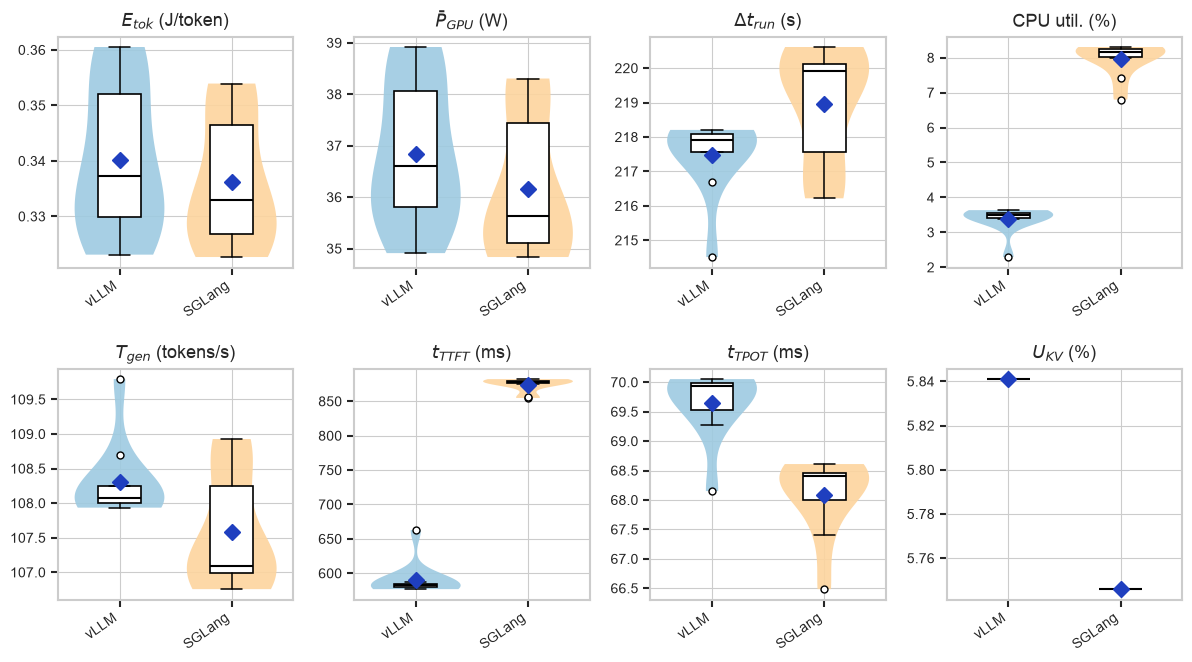

In [39]:
panels = [
    ('E_tok_J', r'$E_{tok}$ (J/token)'), ('P_gpu_mean_W', r'$\bar{P}_{GPU}$ (W)'),
    ('window_s', r'$\Delta t_{run}$ (s)'), ('cpu_util_mean_pct', 'CPU util. (%)'),
    ('T_gen_tps', r'$T_{gen}$ (tokens/s)'), ('ttft_ms_median', r'$t_{TTFT}$ (ms)'),
    ('tpot_ms_median', r'$t_{TPOT}$ (ms)'), ('kv_peak_pct', r'$U_{KV}$ (%)')
]
engines = ['vllm', 'sglang']
labels = ['vLLM', 'SGLang']
colors = ['#9ecae1', '#fdd49e']

fig, axes = plt.subplots(2, 4, figsize=(12, 6.7))
for ax, (metric, title) in zip(axes.flat, panels):
    values = [base_df.loc[base_df.engine == engine, metric].dropna().to_numpy() for engine in engines]
    for position, data, color in zip([0, 1], values, colors):
        if np.ptp(data) > 0:
            violin = ax.violinplot([data], positions=[position], widths=0.8, showextrema=False)
            for body in violin['bodies']:
                body.set_facecolor(color)
                body.set_edgecolor('none')
                body.set_alpha(0.9)
    ax.boxplot(values, positions=[0, 1], widths=0.38, patch_artist=True,
               boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.2),
               medianprops=dict(color='black', linewidth=1.5),
               whiskerprops=dict(color='black', linewidth=1.1),
               capprops=dict(color='black', linewidth=1.1),
               flierprops=dict(marker='o', markersize=5, markerfacecolor='white', markeredgecolor='black'))
    ax.plot([0, 1], [np.mean(data) for data in values], marker='D', color='#1f3fbf',
            markersize=8, linestyle='none', zorder=5)
    ax.set_title(title, fontsize=13, pad=7)
    ax.set_xticks([0, 1], labels, rotation=35, ha='right')
    ax.set_xlim(-0.55, 1.55)
    ax.tick_params(width=1.5, length=5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout(pad=1.0, w_pad=1.5, h_pad=1.8)
plt.show()


### Plot Interpretation

The energy distributions overlap closely, supporting the report's conclusion that neither engine has a meaningful GPU-energy advantage in this baseline. SGLang's CPU utilisation is clearly higher, and its TTFT distribution is shifted upward, indicating that the first token arrives later. These graphs therefore illustrate an operational trade-off rather than an overall winner.


## 6. Factorial Moderation Analysis (RQ3)
This analysis examines whether the engine effect on energy per output token is moderated by workload profile and context size. The plot shows the median $E_{tok}$ for each Llama condition, allowing vLLM and SGLang to be compared at Small (512), Medium (2,048), and Large (8,192) contexts.


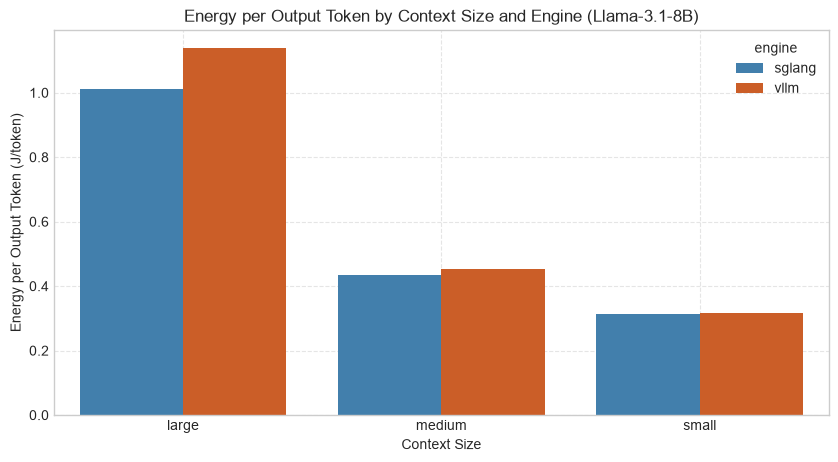

In [40]:
llama_df = df[df.model == 'llama']
grouped_inter = llama_df.groupby(['context', 'profile', 'engine'])['E_tok_J'].median().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=grouped_inter, x='context', y='E_tok_J', hue='engine', ci=None, palette=['#3182bd', '#e6550d'], ax=ax)
ax.set_title('Energy per Output Token by Context Size and Engine (Llama-3.1-8B)')
ax.set_ylabel('Energy per Output Token (J/token)')
ax.set_xlabel('Context Size')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### Interpretation

Context size is the dominant moderator. At Small contexts, the engines have very similar energy per token. At Medium contexts, SGLang is generally lower, and at Large contexts its advantage becomes clear across profiles. The report further shows that prefix reuse changes the size of this gap, but does not reverse the main long-context advantage for SGLang.


## 7. Pareto Decision Matrix (RQ4)
Evaluate Pareto dominance between energy efficiency (tokens/Joule) and end-to-end latency ($t_{\mathrm{E2E}}$).


In [43]:
rq4_matrix = []
cells = llama_df.groupby(['profile', 'context'])

for (prof, ctx), group in cells:
    v = group[group.engine == 'vllm']
    s = group[group.engine == 'sglang']
    
    eta_v, eta_s = v['eta_tok_per_J'].values, s['eta_tok_per_J'].values
    e2e_v, e2e_s = v['e2e_ms_median'].values, s['e2e_ms_median'].values
    edp_v, edp_s = v['EDP_Js'].values, s['EDP_Js'].values
    
    u_eta, p_eta = stats.mannwhitneyu(eta_s, eta_v)
    d_eta, _ = cliff_delta(eta_s, eta_v)
    
    u_e2e, p_e2e = stats.mannwhitneyu(e2e_s, e2e_v)
    d_e2e, _ = cliff_delta(e2e_s, e2e_v)
    
    sig_eta = p_eta < 0.05 and abs(d_eta) >= 0.147
    sig_e2e = p_e2e < 0.05 and abs(d_e2e) >= 0.147
    
    better_eta = 'sglang' if (sig_eta and d_eta > 0) else ('vllm' if (sig_eta and d_eta < 0) else 'none')
    better_e2e = 'sglang' if (sig_e2e and d_e2e < 0) else ('vllm' if (sig_e2e and d_e2e > 0) else 'none')
    
    if better_eta == 'none' and better_e2e == 'none':
        verdict = 'Equivalent'
        winner = 'None'
    elif better_eta != 'none' and better_e2e != 'none' and better_eta != better_e2e:
        verdict = 'Trade-off (EDP tie-breaker)'
        winner = 'sglang' if np.median(edp_s) < np.median(edp_v) else 'vllm'
    else:
        verdict = 'Pareto dominance'
        winner = better_eta if better_eta != 'none' else better_e2e
        
    rq4_matrix.append({
        'Profile': prof,
        'Context': ctx,
        'Efficiency (tok/J) SGLang vs vLLM': f'{(np.median(eta_s)/np.median(eta_v)-1)*100:+.2f}%',
        'E2E Latency SGLang vs vLLM': f'{(np.median(e2e_s)/np.median(e2e_v)-1)*100:+.2f}%',
        'Verdict': verdict,
        'Preferred Engine': winner.upper()
    })

df_rq4 = pd.DataFrame(rq4_matrix)
df_rq4


,Profile,Context,Efficiency (tok/J) SGLang vs vLLM,E2E Latency SGLang vs vLLM,Verdict,Preferred Engine
0,agentic,large,+14.70%,-9.34%,Pareto dominance,SGLANG
1,agentic,medium,+2.52%,+0.50%,Equivalent,NONE
2,agentic,small,+3.11%,-0.70%,Pareto dominance,SGLANG
3,api,large,+12.88%,-7.63%,Pareto dominance,SGLANG
4,api,medium,+3.81%,-1.19%,Pareto dominance,SGLANG
5,api,small,+1.31%,+1.03%,Pareto dominance,VLLM
6,chat,large,+9.61%,-2.31%,Pareto dominance,SGLANG
7,chat,medium,+7.28%,+0.55%,Trade-off (EDP tie-breaker),SGLANG
8,chat,small,-1.37%,+0.87%,Equivalent,NONE
